In [41]:
import rasterio as rio
import geopandas as gpd
import shapely
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

POINTS_FILE = "C:\\Users\\david\\dev\\geospatial-data-registration-toolkit\\data\\points_with_height.gpkg"
RASTER_FILE = "C:\\Users\\david\\dev\\geospatial-data-registration-toolkit\\data\\dtm-ptcloud_921.tif"

Best shift: (0, 0)
Best correlation: 0.9999999999999966


Text(0.5, 1.0, 'Correlation surface')

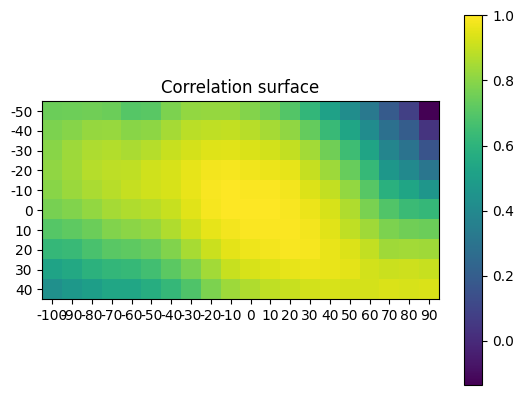

In [50]:
def find_best_shift(raster_file, points_file, height_col="height", x_range=(-100, 100, 10), y_range=(-100, 100, 10)):
    """Search for the shift (dx, dy) that maximizes the Pearson correlation between
    sampled raster elevations at shifted point locations and the provided point heights.

    Args:
        raster_file (str): Path to the raster file.
        points_file (str): Path to the points file (GeoPackage, shapefile, etc.).
        height_col (str): Name of the height column in the points file.
        x_range (tuple or array): If tuple (start, stop, step) it will be passed to np.arange;
                                 otherwise pass an array of x offsets to try.
        y_range (tuple or array): Same as x_range but for y offsets.

    Returns:
        dict: {
            'best_shift': (dx, dy),
            'best_correlation': float,
            'correlations_img': 2D numpy array shaped (len(x_vals), len(y_vals)),
            'x_vals': numpy array of x offsets,
            'y_vals': numpy array of y offsets
        }
    """
    # Normalize ranges to arrays
    def _to_vals(r):
        r = np.asarray(r)
        if r.ndim == 1 and r.size == 3:
            return np.arange(r[0], r[1], r[2])
        return r

    x_vals = _to_vals(x_range)
    y_vals = _to_vals(y_range)

    shifts = list(product(x_vals, y_vals))

    correlations = []

    with rio.open(raster_file) as raster:
        # Read the points, ensuring they are in the same CRS as the raster
        sample_points = gpd.read_file(points_file).to_crs(raster.crs)

        # Extract the xy locations of the points
        xy_points = shapely.get_coordinates(sample_points.geometry)
        provided_heights = sample_points[height_col].values

        for dx, dy in shifts:
            shifted_xy_points = xy_points + np.array([dx, dy])

            # sample_gen returns an iterator of values (one per point)
            sampled = np.array(list(rio.sample.sample_gen(raster, shifted_xy_points))).squeeze()

            # Handle masked arrays
            if np.ma.isMaskedArray(sampled):
                sampled = sampled.filled(np.nan)

            # Keep only points where both are finite
            mask = np.isfinite(sampled) & np.isfinite(provided_heights)

            # TODO this should be updated to peanalize situations where some values are nan
            if mask.sum() < 2:
                corr = np.nan
            else:
                corr = np.corrcoef(sampled[mask], provided_heights[mask])[0, 1]

            correlations.append(corr)

    correlations = np.array(correlations)
    correlations_img = correlations.reshape(len(x_vals), len(y_vals)).T

    # Find best (highest) correlation, ignoring NaNs
    if np.all(np.isnan(correlations)):
        best_shift = (np.nan, np.nan)
        best_corr = np.nan
    else:
        best_idx = np.nanargmax(correlations)
        best_shift = shifts[best_idx]
        best_corr = correlations[best_idx]

    return {
        'best_shift': best_shift,
        'best_correlation': float(best_corr) if not np.isnan(best_corr) else np.nan,
        'correlations_img': correlations_img,
        'x_vals': x_vals,
        'y_vals': y_vals,
    }


# Example usage with the constants defined above
result = find_best_shift(RASTER_FILE, POINTS_FILE, x_range=(-100, 100, 10), y_range=(-50, 50, 10))
print("Best shift:", result['best_shift'])
print("Best correlation:", result['best_correlation'])

plt.imshow(result['correlations_img'])
plt.xticks(ticks=np.arange(len(result["x_vals"])),labels=result["x_vals"])
plt.yticks(ticks=np.arange(len(result["y_vals"])),labels=result["y_vals"])
plt.colorbar()
plt.title('Correlation surface')

Best shift: (0, 0)
Best correlation: 0.9999999999999966


Text(0.5, 1.0, 'Correlation surface')

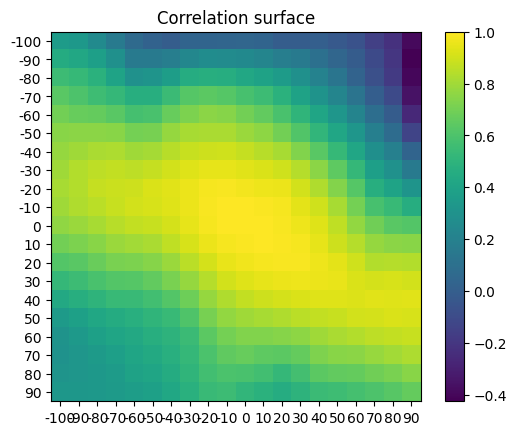

In [51]:
# Example usage with the constants defined above
result = find_best_shift(RASTER_FILE, POINTS_FILE, x_range=(-100, 100, 10), y_range=(-100, 100, 10))
print("Best shift:", result['best_shift'])
print("Best correlation:", result['best_correlation'])

plt.imshow(result['correlations_img'])
plt.xticks(ticks=np.arange(len(result["x_vals"])),labels=result["x_vals"])
plt.yticks(ticks=np.arange(len(result["y_vals"])),labels=result["y_vals"])
plt.colorbar()
plt.title('Correlation surface')